In [1]:
import torch
import torch.distributions as dist
import torch.nn.functional as F
import numpy               as np
import matplotlib.pyplot   as plt

from   scipy               import stats
from   torch               import nn
from   torchvision         import datasets, transforms

In [2]:
# Target distribution
def log_target_beta(beta, X, y, sigma2, Sigma_inv):
    """
    Unnormalized log posterior for Bayesian linear regression:
        y | X, beta ~ N(X beta, sigma2 I)
        beta ~ N(0, Sigma)

    Parameters
    ----------
    beta : torch.Tensor, shape [m, p] or [p]
        Samples of beta. If [p], it will be treated as one sample.
    X : torch.Tensor, shape [n, p]
        Design matrix.
    y : torch.Tensor, shape [n]
        Response vector.
    sigma2 : float or torch.Tensor
        Observation variance.
    Sigma_inv : torch.Tensor, shape [p, p]
        Inverse prior covariance matrix.

    Returns
    -------
    log_post : torch.Tensor, shape [m]
        Unnormalized log posterior evaluated at each beta sample.
    """
    if beta.dim() == 1:
        beta = beta.unsqueeze(0)   # [1, p]

    # Mean under the regression model: X beta
    # beta: [m, p], X.T: [p, n]  ->  [m, n]
    mean = beta @ X.T

    # Likelihood term: -1/(2 sigma2) * || y - X beta ||^2
    resid = y.unsqueeze(0) - mean                      # [m, n]
    log_lik = -0.5 / sigma2 * (resid ** 2).sum(dim=1) # [m]

    # Prior term: -1/2 * beta^T Sigma^{-1} beta
    quad = torch.einsum("bi,ij,bj->b", beta, Sigma_inv, beta)
    log_prior = -0.5 * quad                            # [m]

    return log_lik + log_prior

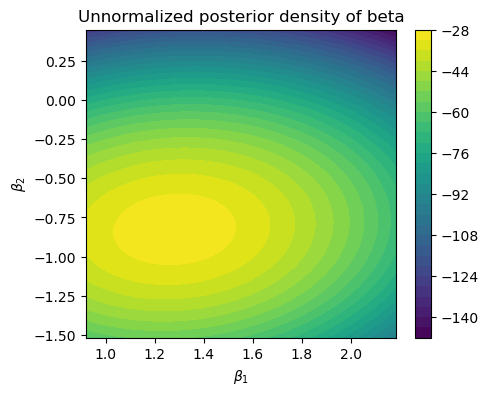

In [ ]:
def log_target_beta(beta, X, y, sigma2, Sigma_inv):
    # log \tilde{\pi}(beta | y, X)
    # = log p(y | X, beta) + log p(beta)   (up to constants)

    if beta.dim() == 1:
        beta = beta.unsqueeze(0)

    # X beta
    mean = beta @ X.T

    # log p(y | X, beta) = -(1/(2 sigma2)) ||y - X beta||^2 + const
    resid = y.unsqueeze(0) - mean
    log_lik = -0.5 / sigma2 * (resid ** 2).sum(dim=1)

    # log p(beta) = -(1/2) beta^T Sigma^{-1} beta + const
    quad = torch.einsum("bi,ij,bj->b", beta, Sigma_inv, beta)
    log_prior = -0.5 * quad

    return log_lik + log_prior

torch.manual_seed(123)

n = 50
p = 2

X = torch.randn(n, p)                          # [n, 2]
beta_true = torch.tensor([1.5, -0.8])         # true beta
sigma2 = 0.5                                  # noise variance

eps = torch.sqrt(torch.tensor(sigma2)) * torch.randn(n)
y = X @ beta_true + eps                       # [n]

Sigma = torch.eye(p)                          # prior covariance
Sigma_inv = torch.inverse(Sigma)              # [2, 2]

# ===== grid over beta1, beta2 =====
mu1, mu2 = mu_post.tolist()  # run later
s1, s2 = torch.sqrt(torch.diag(Sigma_post)).tolist()

beta1 = np.linspace(mu1 - 4*s1, mu1 + 4*s1, 200)
beta2 = np.linspace(mu2 - 4*s2, mu2 + 4*s2, 200)
beta1_s, beta2_s = np.meshgrid(beta1, beta2)

grid_points = np.stack([beta1_s, beta2_s], axis=-1)              # [200, 200, 2]
grid_points = torch.tensor(grid_points, dtype=torch.float32)

flat_grid = grid_points.view(-1, 2)                              # [200*200, 2]
log_post = log_target_beta(flat_grid, X, y, sigma2, Sigma_inv)   # [200*200]

# numerical stabilization: subtract max before exp
density = torch.exp(log_post - log_post.max()).view(beta1_s.shape)
density = density.detach().cpu().numpy()

plt.figure(figsize=(5, 4))
plt.title("Unnormalized posterior density of beta")
plt.xlabel(r'$\beta_1$')
plt.ylabel(r'$\beta_2$')
plt.contourf(beta1_s, beta2_s, log_post.view(beta1_s.shape).cpu().numpy(), levels=30)
plt.colorbar()
plt.show()

In [13]:
# Planar flows: Tz = z .+ h(w'z+b) *u    z,u,w in R^k,  b in R
class Planar(nn.Module):

    ## parameters u,w,b of the transformation
    def __init__(self, size=2, init_sigma=0.01):
        super().__init__()
        self.u = nn.Parameter(torch.randn(1, size).normal_(0, init_sigma))  # initilize u in R^k, k=size
        self.w = nn.Parameter(torch.randn(1, size).normal_(0, init_sigma))  # initilize w in R^k, k=size
        self.b = nn.Parameter(torch.zeros(1))                               # initilize b in R

    @property
    def normalized_u(self):
        def _m(x):
            return -1.0 + F.softplus(x)

        wu = (self.w * self.u).sum()
        w_norm_sq = (self.w ** 2).sum() + 1e-8
        return self.u + ((_m(wu) - wu) * self.w / w_norm_sq)

    # ============================================================    
    def psi(self, eta):
        """
        ψ(z) =h′(w^tz+b)w  See eq(11): Rezende et al. VI with Normalizing Flows https://arxiv.org/pdf/1505.05770.pdf
        """
        return self.h_prime(eta @ self.w.t() + self.b) @ self.w

    # define h in  Tz = z .+ h(w'z+b) *u ========================= 
    def h(self, x):
        return torch.tanh(x)

    # define h' in  Tz = z .+ h(w'z+b) *u ======================== 
    def h_prime(self, eta):
        return 1 - torch.tanh(eta) ** 2

    # define Tz = z .+ h(w'z+b) *u =============================== 
    def forward(self, eta):
        if isinstance(eta, tuple):
            eta, accumulating_ldj = eta
        else:
            eta, accumulating_ldj = eta, 0
            
        psi = self.psi(eta)
        u   = self.normalized_u        
        det = (1 + psi @ u.t())                   # determinant of jacobian
        ldJ = torch.log(torch.abs(det) + 1e-6)    # log |det J_T|
        wetab = eta @ self.w.t() + self.b
        Teta  = eta + (u * self.h(wetab))

        return Teta, ldJ + accumulating_ldj         # transformation 

In [15]:
# define T = T_K * ... * T_2 * T_1
class Flow(nn.Module):
    def __init__(self, dim=2, n_flows=10):
        super().__init__()
        self.flow    = nn.Sequential(*[Planar(dim) for _ in range(n_flows) ])
        self.mu      = nn.Parameter(torch.randn(dim, ).normal_(0, 0.01))
        self.log_var = nn.Parameter(torch.randn(dim, ).normal_(1, 0.01))

    def forward(self, shape):
        std     = torch.exp(0.5 * self.log_var)
        eps     = torch.randn(shape)              # unit gaussian
        eta0      = self.mu + eps * std             # base-dist is  z0 = mu + std * eps  eps ~ N(0,1) & var=std^2 
        etak, ldj = self.flow(eta0)                   # apply transform T to z0
        return eta0, etak, ldj, self.mu, self.log_var # return 1) base-dist z0, 2) transf zk=T(z0) 3) (mu, log_var)  

In [20]:
# negative ELBO = E_Q0 [ log Q0(Z_0) -sum_k log|T_k|  -log pi_Y(T(Z0)) ] where pi_Y is the target distribution
def det_loss(mu, log_var, eta_0, eta_k, ldj, X, y, sigma2, Sigma_inv):
    # Monte Carlo approximation of
    #     E_{q_K(eta)} [ log q_K(eta) - log \tilde{\pi}(eta | y, X) ]
    # where \tilde{\pi} is the unnormalized posterior target.

    # Number of Monte Carlo samples in the batch
    m = eta_0.size(0)

    # Base distribution q_0:
    #     q_0(eta_0) = N(mu, diag(exp(log_var)))
    std = torch.exp(0.5 * log_var)

    # Log-density under the base distribution:
    #     log q_0(eta_0)
    log_qeta0 = torch.distributions.Normal(mu, std).log_prob(eta_0).sum(dim=1)

    # Change-of-variables formula:
    #     log q_K(eta_k)
    #   = log q_0(eta_0) - log |det J_T(eta_0)|
    if ldj.dim() > 1:
        ldj = ldj.squeeze(-1)
    log_qetak = log_qeta0 - ldj

    # Unnormalized log-posterior target:
    #     log \tilde{\pi}(eta_k | y, X)
    #   = log p(y | X, eta_k) + log p(eta_k) + const
    log_target = log_target_beta(eta_k, X, y, sigma2, Sigma_inv)

    # Reverse-KL objective up to an additive constant:
    #     E_{q_K}[ log q_K(eta) - log \tilde{\pi}(eta | y, X) ]
    return (log_qetak - log_target).mean()

In [17]:
# optimization  min KL(Q_NF || pi_Y)
def train_flow_beta(flow, shape, X, y, sigma2, Sigma_inv, epochs=1000, lr=1e-2):
    optim = torch.optim.Adam(flow.parameters(), lr=lr)
    losses = []

    for i in range(epochs):
        optim.zero_grad()

        eta0, etak, ldj, mu, log_var = flow(shape=shape)

        loss = det_loss(mu=mu, log_var=log_var, eta_0=eta0, eta_k=etak, ldj=ldj,
            X=X, y=y, sigma2=sigma2, Sigma_inv=Sigma_inv)

        loss.backward()
        optim.step()

        losses.append(loss.item())

        if (i + 1) % 100 == 0 or i == 0:
            print(f"epoch {i+1:4d} | loss = {loss.item():.4f}")

    return losses

In [10]:
def show_beta_samples(beta0, betaK, mu, title="Samples"):
    alpha = 0.2

    mask_1 = (beta0[:, 0] > mu[0]) & (beta0[:, 1] > mu[1])
    mask_2 = (beta0[:, 0] > mu[0]) & (beta0[:, 1] < mu[1])
    mask_3 = (beta0[:, 0] < mu[0]) & (beta0[:, 1] > mu[1])
    mask_4 = (beta0[:, 0] < mu[0]) & (beta0[:, 1] < mu[1])

    beta0 = beta0.detach().cpu()
    betaK = betaK.detach().cpu()

    plt.figure(figsize=(12, 4))
    plt.suptitle(title)

    plt.subplot(1, 2, 1)
    plt.title(r'Base samples $\beta_0$')
    plt.scatter(beta0[:, 0][mask_1], beta0[:, 1][mask_1], color='C0', alpha=alpha)
    plt.scatter(beta0[:, 0][mask_2], beta0[:, 1][mask_2], color='C1', alpha=alpha)
    plt.scatter(beta0[:, 0][mask_3], beta0[:, 1][mask_3], color='C3', alpha=alpha)
    plt.scatter(beta0[:, 0][mask_4], beta0[:, 1][mask_4], color='C4', alpha=alpha)
    plt.xlabel(r'$\beta_1$')
    plt.ylabel(r'$\beta_2$')

    plt.subplot(1, 2, 2)
    plt.title(r'Flow samples $\beta_K$')
    plt.scatter(betaK[:, 0][mask_1], betaK[:, 1][mask_1], color='C0', alpha=alpha)
    plt.scatter(betaK[:, 0][mask_2], betaK[:, 1][mask_2], color='C1', alpha=alpha)
    plt.scatter(betaK[:, 0][mask_3], betaK[:, 1][mask_3], color='C3', alpha=alpha)
    plt.scatter(betaK[:, 0][mask_4], betaK[:, 1][mask_4], color='C4', alpha=alpha)
    plt.xlabel(r'$\beta_1$')
    plt.ylabel(r'$\beta_2$')

    plt.tight_layout()
    plt.show()

In [11]:
def posterior_closed_form(X, y, sigma2, Sigma):
    Sigma_inv = torch.inverse(Sigma)
    Sigma_post = torch.inverse((X.T @ X) / sigma2 + Sigma_inv)
    mu_post = Sigma_post @ (X.T @ y) / sigma2
    return mu_post, Sigma_post


def summarize_flow_samples(beta_samples):
    mu_hat = beta_samples.mean(dim=0)
    centered = beta_samples - mu_hat
    cov_hat = centered.T @ centered / (beta_samples.shape[0] - 1)
    return mu_hat, cov_hat

epoch    1 | loss = 145.3545
epoch  100 | loss = 39.6966
epoch  200 | loss = 29.3000
epoch  300 | loss = 24.7786
epoch  400 | loss = 22.5824
epoch  500 | loss = 21.3275
epoch  600 | loss = 20.3736
epoch  700 | loss = 19.8600
epoch  800 | loss = 19.5274
epoch  900 | loss = 19.3604
epoch 1000 | loss = 19.2230
epoch 1100 | loss = 19.1570
epoch 1200 | loss = 19.1039
epoch 1300 | loss = 19.0997
epoch 1400 | loss = 19.0625
epoch 1500 | loss = 19.0477
epoch 1600 | loss = 19.0412
epoch 1700 | loss = 19.0355
epoch 1800 | loss = 19.0227
epoch 1900 | loss = 19.0248
epoch 2000 | loss = 19.0209
epoch 2100 | loss = 19.0160
epoch 2200 | loss = 19.0140
epoch 2300 | loss = 19.0139
epoch 2400 | loss = 19.0114
epoch 2500 | loss = 19.0119
epoch 2600 | loss = 19.0124
epoch 2700 | loss = 19.0113
epoch 2800 | loss = 19.0113
epoch 2900 | loss = 19.0118
epoch 3000 | loss = 19.0110
epoch 3100 | loss = 19.0112
epoch 3200 | loss = 19.0108
epoch 3300 | loss = 19.0118
epoch 3400 | loss = 19.0119
epoch 3500 | loss =

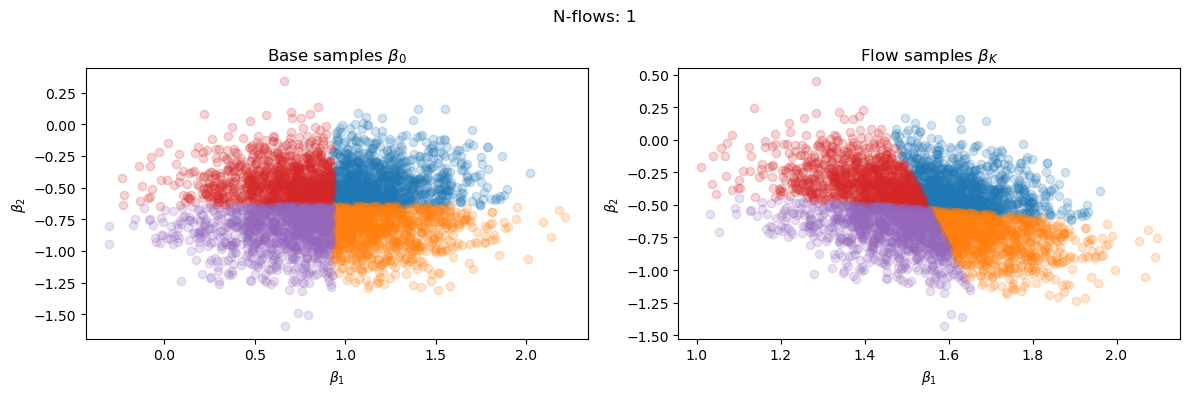


N-flows: 1
flow mean:
 tensor([ 1.5495, -0.5318])
true mean:
 tensor([ 1.5516, -0.5353])
flow covariance:
 tensor([[ 0.0245, -0.0139],
        [-0.0139,  0.0575]])
true covariance:
 tensor([[ 0.0250, -0.0153],
        [-0.0153,  0.0603]])
mean error: 0.004021829459816217
cov error : 0.0033667562529444695
epoch    1 | loss = 84.4205
epoch  100 | loss = 22.8920
epoch  200 | loss = 20.0336
epoch  300 | loss = 19.2068
epoch  400 | loss = 19.0604
epoch  500 | loss = 19.0171
epoch  600 | loss = 19.0218
epoch  700 | loss = 19.0167
epoch  800 | loss = 19.0144
epoch  900 | loss = 19.0151
epoch 1000 | loss = 19.0123
epoch 1100 | loss = 19.0119
epoch 1200 | loss = 19.0119
epoch 1300 | loss = 19.0168
epoch 1400 | loss = 19.0139
epoch 1500 | loss = 19.0133
epoch 1600 | loss = 19.0105
epoch 1700 | loss = 19.0110
epoch 1800 | loss = 19.0139
epoch 1900 | loss = 19.0137
epoch 2000 | loss = 19.0122
epoch 2100 | loss = 19.0126
epoch 2200 | loss = 19.0124
epoch 2300 | loss = 19.0152
epoch 2400 | loss = 1

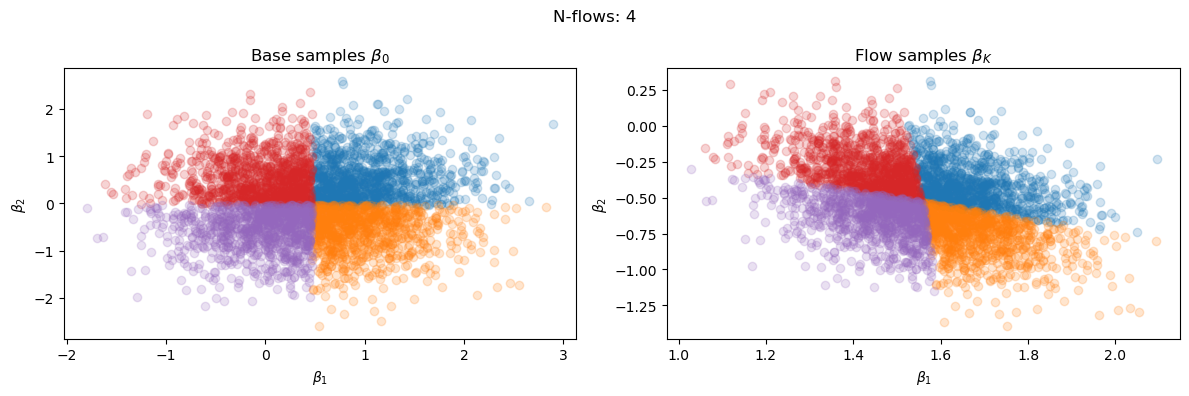


N-flows: 4
flow mean:
 tensor([ 1.5566, -0.5223])
true mean:
 tensor([ 1.5516, -0.5353])
flow covariance:
 tensor([[ 0.0246, -0.0146],
        [-0.0146,  0.0590]])
true covariance:
 tensor([[ 0.0250, -0.0153],
        [-0.0153,  0.0603]])
mean error: 0.01396716758608818
cov error : 0.0016558024799451232
epoch    1 | loss = 75.1119
epoch  100 | loss = 19.2218
epoch  200 | loss = 19.0332
epoch  300 | loss = 19.0117
epoch  400 | loss = 19.0124
epoch  500 | loss = 19.0126
epoch  600 | loss = 19.0127
epoch  700 | loss = 19.0108
epoch  800 | loss = 19.0143
epoch  900 | loss = 19.0109
epoch 1000 | loss = 19.0112
epoch 1100 | loss = 19.0112
epoch 1200 | loss = 19.0131
epoch 1300 | loss = 19.0110
epoch 1400 | loss = 19.0115
epoch 1500 | loss = 19.0116
epoch 1600 | loss = 19.0159
epoch 1700 | loss = 19.0115
epoch 1800 | loss = 19.0119
epoch 1900 | loss = 19.0128
epoch 2000 | loss = 19.0126
epoch 2100 | loss = 19.0108
epoch 2200 | loss = 19.0120
epoch 2300 | loss = 19.0122
epoch 2400 | loss = 19

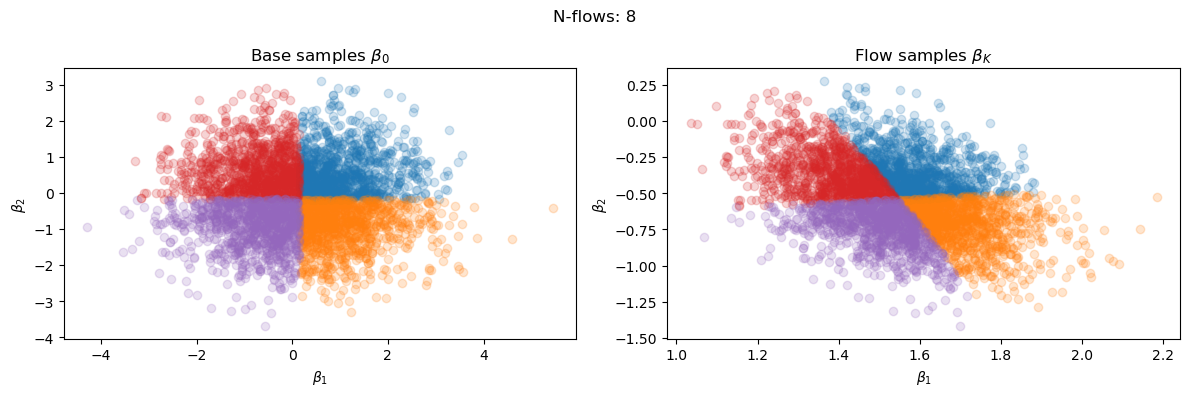


N-flows: 8
flow mean:
 tensor([ 1.5446, -0.5449])
true mean:
 tensor([ 1.5516, -0.5353])
flow covariance:
 tensor([[ 0.0249, -0.0163],
        [-0.0163,  0.0625]])
true covariance:
 tensor([[ 0.0250, -0.0153],
        [-0.0153,  0.0603]])
mean error: 0.011835324577987194
cov error : 0.0026339765172451735
epoch    1 | loss = 69.6655
epoch  100 | loss = 19.0184
epoch  200 | loss = 19.0130
epoch  300 | loss = 19.0141
epoch  400 | loss = 19.0142
epoch  500 | loss = 19.0132
epoch  600 | loss = 19.0136
epoch  700 | loss = 19.0119
epoch  800 | loss = 19.0118
epoch  900 | loss = 19.0123
epoch 1000 | loss = 19.0131
epoch 1100 | loss = 19.0140
epoch 1200 | loss = 19.0121
epoch 1300 | loss = 19.0123
epoch 1400 | loss = 19.0146
epoch 1500 | loss = 19.0121
epoch 1600 | loss = 19.0169
epoch 1700 | loss = 19.0141
epoch 1800 | loss = 19.0136
epoch 1900 | loss = 19.0140
epoch 2000 | loss = 19.0144
epoch 2100 | loss = 19.0119
epoch 2200 | loss = 19.0116
epoch 2300 | loss = 19.0115
epoch 2400 | loss = 1

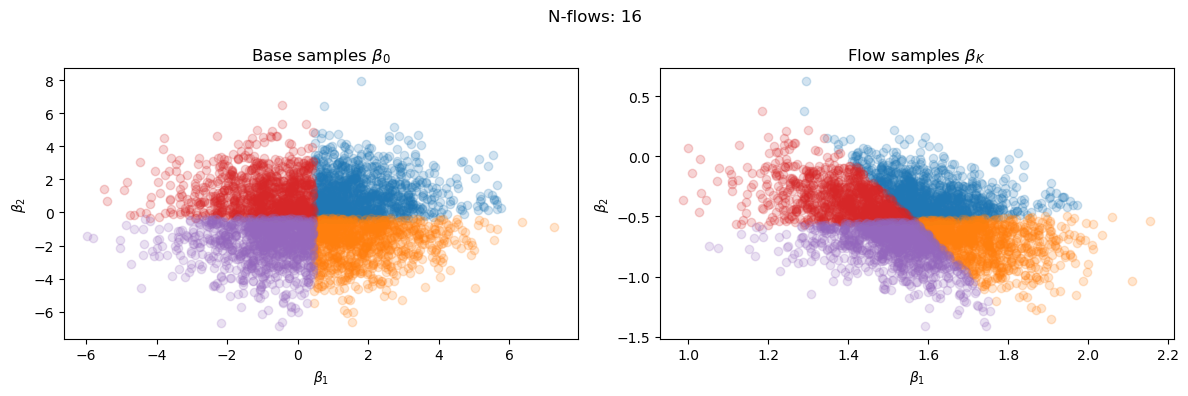


N-flows: 16
flow mean:
 tensor([ 1.5615, -0.5337])
true mean:
 tensor([ 1.5516, -0.5353])
flow covariance:
 tensor([[ 0.0254, -0.0148],
        [-0.0148,  0.0609]])
true covariance:
 tensor([[ 0.0250, -0.0153],
        [-0.0153,  0.0603]])
mean error: 0.010046504437923431
cov error : 0.0010858885943889618


In [ ]:
shape = (6000, 2)   # 6000 base draws, beta is 2-dimensional
n_eps = 5000

# example prior covariance
Sigma = torch.eye(2)
Sigma_inv = torch.inverse(Sigma)

# closed-form posterior for comparison
mu_post, Sigma_post = posterior_closed_form(X, y, sigma2, Sigma)

for n_flows in [1, 4, 8, 16]:
    flow = Flow(dim=2, n_flows=n_flows)

    losses = train_flow_beta(flow,shape=shape,
        X=X,y=y, sigma2=sigma2,Sigma_inv=Sigma_inv,
        epochs=n_eps,
    )

    with torch.no_grad():
        beta0, betaK, ldj, mu, log_var = flow(shape=(4000, 2))

        # optional: sample scatter before/after flow
        show_beta_samples(
            beta0,betaK,mu.squeeze(0),
            title=f"N-flows: {n_flows}"
        )

        # compare flow samples with exact posterior
        mu_hat, cov_hat = summarize_flow_samples(betaK)

        print(f"\nN-flows: {n_flows}")
        print("flow mean:\n", mu_hat)
        print("true mean:\n", mu_post)
        print("flow covariance:\n", cov_hat)
        print("true covariance:\n", Sigma_post)
        print("mean error:", torch.norm(mu_hat - mu_post).item())
        print("cov error :", torch.norm(cov_hat - Sigma_post).item())